## Feature Engineering for Financial Misinformation Detection

Financial misinformation can differ from authentic news not only in factual
content but also in linguistic patterns.

Therefore, multiple feature categories are extracted:

- sentiment features capture emotional manipulation
- readability features capture writing complexity
- linguistic features capture writing style differences
- FinBERT representations capture financial semantic information

These features are combined to support downstream detection models.

## Imports

In [ ]:
import os
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import textstat


import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModel
)

## Load dataset

The dataset consists of:

- Real financial news articles
- AI-generated financial articles

Both datasets are combined into a single classification dataset.

Labels:

- 0 = Real article
- 1 = AI-generated article

In [ ]:
# Paths
PROCESSED_PATH = "data/processed"

os.makedirs(PROCESSED_PATH, exist_ok=True)

df = pd.read_csv(
    f"{PROCESSED_PATH}/synthetic_financial_news.csv"
)

df.head()

,generated_article,original_article,prompt_type,source_type,label,company,length
0,McDonald's is bringing back its Fried Apple Pi...,McDonald's is bringing back its Fried Apple Pi...,original,real,0,NaN,87
1,We recently published Jim Cramer Discussed Exp...,We recently published Jim Cramer Discussed Exp...,original,real,0,NaN,56
2,(Bloomberg) -- For the first time in four year...,(Bloomberg) -- For the first time in four year...,original,real,0,NaN,81
3,Goldman Sachs now sees a smaller chance of a r...,Goldman Sachs now sees a smaller chance of a r...,original,real,0,NaN,57
4,Stock futures were tumbling on Tuesday as inve...,Stock futures were tumbling on Tuesday as inve...,original,real,0,NaN,49


In [ ]:
print(df.shape)

print(
    df["label"].value_counts()
)

(400, 7)
label
1    300
0    100
Name: count, dtype: int64


In [ ]:
# Prepare Text Column
df = df.rename(
    columns={
        "generated_article":"article"
    }
)

df = df[
    [
        "article",
        "label",
        "source_type",
        "prompt_type"
    ]
]

df.head()

,article,label,source_type,prompt_type
0,McDonald's is bringing back its Fried Apple Pi...,0,real,original
1,We recently published Jim Cramer Discussed Exp...,0,real,original
2,(Bloomberg) -- For the first time in four year...,0,real,original
3,Goldman Sachs now sees a smaller chance of a r...,0,real,original
4,Stock futures were tumbling on Tuesday as inve...,0,real,original


## VADER Sentiment

**Sentiment Feature Extraction (VADER)**

VADER (Valence Aware Dictionary and sEntiment Reasoner)
is a lexicon-based sentiment analysis method.

The following sentiment scores are extracted:

- Positive score
- Negative score
- Neutral score
- Compound score

These features help quantify emotional tone in financial articles.

In [ ]:
analyzer = SentimentIntensityAnalyzer()

In [ ]:
# Create sentiment function
def vader_features(text):

    scores = analyzer.polarity_scores(
        str(text)
    )

    return pd.Series(
        [
            scores["pos"],
            scores["neg"],
            scores["neu"],
            scores["compound"]
        ]
    )

In [ ]:
df[
[
"positive_score",
"negative_score",
"neutral_score",
"vader_compound"
]
] = df["article"].apply(
    vader_features
)

In [ ]:
df[
    [
        "positive_score",
        "negative_score",
        "neutral_score",
        "vader_compound"
    ]
].describe()

,positive_score,negative_score,neutral_score,vader_compound
count,400.000000,400.000000,400.000000,400.000000
mean,0.134710,0.048027,0.817263,0.520415
std,0.070243,0.053984,0.077824,0.556113
min,0.000000,0.000000,0.565000,-0.983600
25%,0.082000,0.000000,0.761000,0.296000
50%,0.126000,0.025000,0.804000,0.734100
75%,0.184000,0.088250,0.874000,0.966175
max,0.327000,0.289000,1.000000,0.998300


In [ ]:
df.head()

,article,label,source_type,prompt_type,positive_score,negative_score,neutral_score,vader_compound
0,McDonald's is bringing back its Fried Apple Pi...,0,real,original,0.112,0.020,0.868,0.8271
1,We recently published Jim Cramer Discussed Exp...,0,real,original,0.037,0.055,0.908,-0.2732
2,(Bloomberg) -- For the first time in four year...,0,real,original,0.111,0.095,0.795,0.1280
3,Goldman Sachs now sees a smaller chance of a r...,0,real,original,0.202,0.234,0.565,-0.3612
4,Stock futures were tumbling on Tuesday as inve...,0,real,original,0.061,0.000,0.939,0.4767


## FinBERT Sentiment

**Financial Sentiment Analysis (FinBERT)**

FinBERT is a transformer model trained specifically on financial text.

Traditional features capture measurable writing patterns but may miss deeper
semantic relationships. FinBERT embeddings represent each article as a numerical vector containing
contextual financial language information.

For each article, a sentiment label is predicted:

- Positive
- Negative
- Neutral

In [ ]:
# Load model
finbert_tokenizer = AutoTokenizer.from_pretrained(
    "ProsusAI/finbert"
)

finbert_model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# Prediction function
def finbert_sentiment(text):

    inputs = finbert_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():

        output = finbert_model(**inputs)

    probs = torch.nn.functional.softmax(
        output.logits,
        dim=1
    )

    label = torch.argmax(
        probs
    ).item()

    labels = [
        "positive",
        "negative",
        "neutral"
    ]

    return labels[label]

In [ ]:
tqdm.pandas()

df["finbert_sentiment"] = (
    df["article"]
    .progress_apply(
        finbert_sentiment
    )
)

100%|██████████| 400/400 [04:46<00:00,  1.40it/s]


In [ ]:
df["finbert_sentiment"].value_counts()

,count
finbert_sentiment,
positive,175
negative,173
neutral,52


AI-generated articles include both manipulated misinformation samples
(bullish/bearish) and AI-generated rewrites.

The objective is to identify AI-generated financial content patterns.

## Readability Features

Readability metrics measure how easy a text is to understand.

The following features are extracted:

- Flesch Reading Ease
- Gunning Fog Index

These metrics may help identify stylistic differences between
human-written and AI-generated financial content.

In [ ]:
def readability_features(text):

    return pd.Series(
        [
            textstat.flesch_reading_ease(text),
            textstat.gunning_fog(text)
        ]
    )

In [ ]:
df[
[
"flesch_score",
"gunning_fog"
]
] = df["article"].apply(
    readability_features
)

In [ ]:
df[
    [
        "flesch_score",
        "gunning_fog"
    ]
].describe()

,flesch_score,gunning_fog
count,400.000000,400.000000
mean,25.796495,18.284636
std,21.843549,4.776006
min,-16.871330,5.659091
25%,9.171831,14.638182
50%,19.505802,19.443021
75%,42.136772,22.005142
max,90.645966,27.052814


## Linguistic Features

Basic linguistic characteristics are extracted from each article.

Features include:

- Word count
- Sentence count
- Average sentence length
- Capitalization ratio
- Punctuation count

These features capture writing style and text structure.

In [ ]:
def linguistic_features(text):

    text = str(text)

    words = text.split()

    sentences = re.split(
        r'[.!?]+',
        text
    )


    return pd.Series(
        [

        len(words),

        len(sentences),

        len(words)/max(
            len(sentences),
            1
        ),

        sum(
            1 for c in text if c.isupper()
        )
        /
        max(len(text),1),

        sum(
            1 for c in text
            if c in string.punctuation
        )

        ]
    )

In [ ]:
df[
[
"word_count",
"sentence_count",
"avg_sentence_length",
"capital_ratio",
"punctuation_count"
]
] = df["article"].apply(
    linguistic_features
)

In [ ]:
df[
    [
        "word_count",
        "sentence_count",
        "avg_sentence_length"
    ]
].describe()

,word_count,sentence_count,avg_sentence_length
count,400.00000,400.000000,400.000000
mean,140.74250,7.617500,18.090828
std,79.93996,3.198714,6.063692
min,30.00000,2.000000,5.600000
25%,68.00000,5.000000,13.729167
50%,111.50000,8.000000,18.200000
75%,216.25000,10.000000,22.525000
max,363.00000,17.000000,40.500000


In [ ]:
df.head()

,article,label,source_type,prompt_type,positive_score,negative_score,neutral_score,vader_compound,finbert_sentiment,flesch_score,gunning_fog,word_count,sentence_count,avg_sentence_length,capital_ratio,punctuation_count
0,McDonald's is bringing back its Fried Apple Pi...,0,real,original,0.112,0.020,0.868,0.8271,positive,71.695862,9.109360,87.0,9.0,9.666667,0.048780,16.0
1,We recently published Jim Cramer Discussed Exp...,0,real,original,0.037,0.055,0.908,-0.2732,negative,61.532500,11.325926,56.0,4.0,14.000000,0.112045,17.0
2,(Bloomberg) -- For the first time in four year...,0,real,original,0.111,0.095,0.795,0.1280,positive,48.638333,15.666667,81.0,3.0,27.000000,0.106212,10.0
3,Goldman Sachs now sees a smaller chance of a r...,0,real,original,0.202,0.234,0.565,-0.3612,negative,78.087039,9.208772,57.0,6.0,9.500000,0.023333,11.0
4,Stock futures were tumbling on Tuesday as inve...,0,real,original,0.061,0.000,0.939,0.4767,negative,34.868912,17.145578,49.0,6.0,8.166667,0.034783,11.0


## FinBERT Embeddings

To capture semantic information beyond handcrafted features,
dense vector representations are generated using FinBERT.

In [ ]:
# Load embedding model
embedding_tokenizer = AutoTokenizer.from_pretrained(
    "ProsusAI/finbert"
)

embedding_model = AutoModel.from_pretrained(
    "ProsusAI/finbert"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Embedding function
def create_embedding(text):

    inputs = embedding_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    )

    with torch.no_grad():

        output = embedding_model(
            **inputs
        )

    embedding = (
        output.last_hidden_state
        .mean(dim=1)
        .squeeze()
        .numpy()
    )

    return embedding

In [ ]:
# Generate
embeddings = []

for text in tqdm(df["article"]):

    embeddings.append(
        create_embedding(text)
    )

embeddings = np.array(
    embeddings
)

embeddings.shape

100%|██████████| 400/400 [04:54<00:00,  1.36it/s]


(400, 768)

Each article is represented as a 768-dimensional embedding vector.

In [ ]:
# Save embeddings
np.save(
    f"{PROCESSED_PATH}/finbert_embeddings.npy",
    embeddings
)

The embeddings are stored separately to reduce dataset size and
will be used in downstream machine learning models.

In [ ]:
# Save Feature Dataset
df.to_csv(
    f"{PROCESSED_PATH}/features_dataset.csv",
    index=False
)

print("Saved")

Saved


**Extracted Feature Summary**

The final dataset contains:

| Feature Type | Examples |
|---|---|
| Sentiment | VADER scores, FinBERT sentiment |
| Readability | Flesch score, Gunning Fog |
| Linguistic | Word count, punctuation, sentence length |
| Semantic | FinBERT embeddings |

These features are used in the following modelling stage.

## Visualizations

Exploratory analysis is performed to examine feature distributions
between real and AI-generated articles.

The goal is to identify patterns that may contribute to successful
misinformation detection.

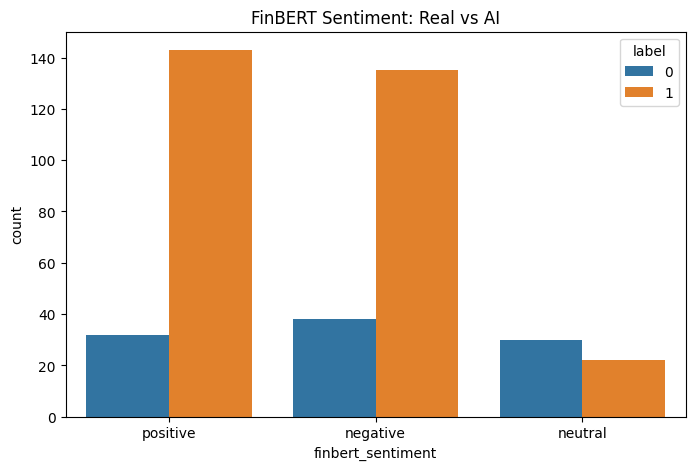

In [ ]:
# Sentiment
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="finbert_sentiment",
    hue="label"
)

plt.title(
    "FinBERT Sentiment: Real vs AI"
)

plt.show()

The sentiment distribution shows differences between real and AI-generated
articles. AI-generated samples display stronger sentiment polarity, suggesting
that emotional expression may provide useful signals for detection.

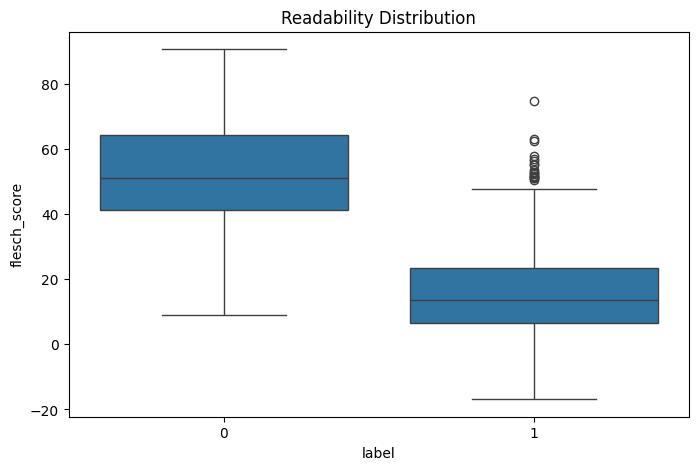

In [ ]:
# Readability
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="flesch_score"
)

plt.title(
    "Readability Distribution"
)

plt.show()

AI-generated samples show different readability characteristics compared with real articles. This indicates that writing style features may contribute to classification performance.

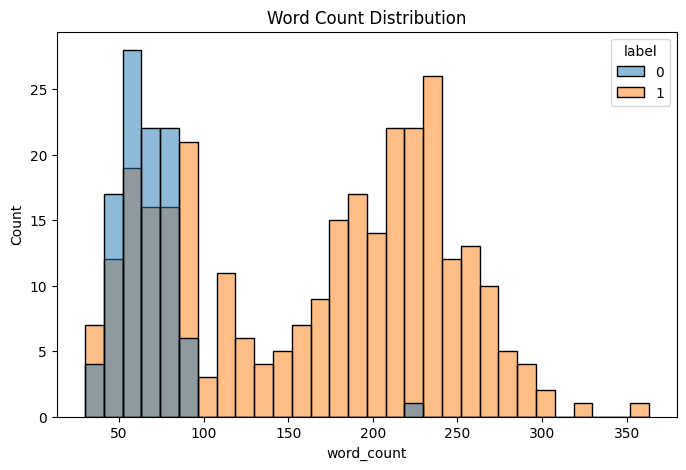

In [ ]:
# Word Count
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=30
)

plt.title(
    "Word Count Distribution"
)

plt.show()

AI-generated articles show different length distributions compared with real articles. Text length may therefore provide an additional linguistic feature
for detection models.

In [ ]:
# Final check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   article              400 non-null    object 
 1   label                400 non-null    int64  
 2   source_type          400 non-null    object 
 3   prompt_type          400 non-null    object 
 4   positive_score       400 non-null    float64
 5   negative_score       400 non-null    float64
 6   neutral_score        400 non-null    float64
 7   vader_compound       400 non-null    float64
 8   finbert_sentiment    400 non-null    object 
 9   flesch_score         400 non-null    float64
 10  gunning_fog          400 non-null    float64
 11  word_count           400 non-null    float64
 12  sentence_count       400 non-null    float64
 13  avg_sentence_length  400 non-null    float64
 14  capital_ratio        400 non-null    float64
 15  punctuation_count    400 non-null    flo

This notebook transformed raw financial text into machine-learning-ready
representations.

The resulting feature dataset combines traditional NLP features with
financial-domain transformer representations.

These features support comparison between classical machine learning models
and transformer-based approaches for misinformation detection.